In [6]:
%pip install seaborn xgboost


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
import xgboost as xgb
import scipy
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ndcg_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 1000)

DIRS = {
    'models': '../models',
    'results': '../results',
    'figures': '../results/figures',
    'ltr_data': '../data/processed/ltr_datasets',
    'split_data': '../data/processed/split_datasets'
}

for dir_path in DIRS.values():
    os.makedirs(dir_path, exist_ok=True)

print("Environment setup complete. Directories configured successfully.")

Environment setup complete. Directories configured successfully.


In [8]:
print("=" * 80)
print("STEP 0: VERIFY ACTUAL DATA STRUCTURE")
print("=" * 80)

DIRS = {
    'models': '../models',
    'results': '../results',
    'figures': '../results/figures',
    'ltr_data': '../data/processed/ltr_datasets',
    'split_data': '../data/processed/split_datasets'
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# Load with CORRECT file names
ltr_train = pd.read_csv(f"{DIRS['ltr_data']}/ltr_train_dataset.csv")
ltr_val   = pd.read_csv(f"{DIRS['ltr_data']}/ltr_validation_dataset.csv")
ltr_test  = pd.read_csv(f"{DIRS['ltr_data']}/ltr_test_dataset.csv")
employee_candidate_pool = pd.read_csv(f"{DIRS['ltr_data']}/employee_candidate_pool.csv")

train_groups = json.load(open(f"{DIRS['ltr_data']}/train_group_sizes.json"))
val_groups   = json.load(open(f"{DIRS['ltr_data']}/validation_group_sizes.json"))
test_groups  = json.load(open(f"{DIRS['ltr_data']}/test_group_sizes.json"))

with open(f"{DIRS['ltr_data']}/ltr_feature_columns.json", "r") as f:
    feature_meta = json.load(f)

print(f"Train: {ltr_train.shape}, Val: {ltr_val.shape}, Test: {ltr_test.shape}")
print(f"\nTrain columns: {list(ltr_train.columns)}")
print(f"\nFeature meta keys: {list(feature_meta.keys()) if isinstance(feature_meta, dict) else 'is list'}")

# Check what's available
print(f"\n'sample_weight' in train: {'sample_weight' in ltr_train.columns}")
print(f"'employee_historical_task_count' in train: {'employee_historical_task_count' in ltr_train.columns}")
print(f"'employee_project_task_count' in test: {'employee_project_task_count' in ltr_test.columns}")

print(f"\nEmployee pool: {employee_candidate_pool.shape}")
print(f"Pool columns: {list(employee_candidate_pool.columns)}")

print(f"\nGroup sizes - Train: {len(train_groups)} groups, sum={sum(train_groups)}")
print(f"Group sizes - Val: {len(val_groups)} groups, sum={sum(val_groups)}")
print(f"Group sizes - Test: {len(test_groups)} groups, sum={sum(test_groups)}")

# Relevance distribution
for name, df in [("train", ltr_train), ("val", ltr_val), ("test", ltr_test)]:
    print(f"\n{name} positive rate: {df['relevance'].mean():.3f} ({df['relevance'].sum()} / {len(df)})")


STEP 0: VERIFY ACTUAL DATA STRUCTURE
Train: (83741, 61), Val: (17934, 61), Test: (17983, 61)

Train columns: ['Task_ID', 'Employee_ID', 'relevance', 'Task_Priority', 'Estimated_Planned_Hours', 'Task_Text_Length', 'Task_Word_Count', 'Task_Description_Length', 'Task_Name_Length', 'Has_Task_Description', 'Created_Year', 'Created_Month', 'Created_DayOfWeek', 'Created_Quarter', 'Days_To_Deadline', 'Has_Deadline', 'Planned_Hours_Log', 'Planned_Task_Size', 'Task_Skill_Count', 'Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship', 'Project_Task_Count_Train', 'Project_Avg_Skill_Count_Train', 'Project_Avg_Planned_Hours_Train', 'Created_Date', 'Project_Name', 'employee_historical_task_count', 'employee_historical_avg_planned_hours', 'employee_historical_avg_skill_count', 'employee_historical

In [9]:
print("=" * 80)
print("STEP 1: CONFIGURE FEATURES")
print("=" * 80)

# Handle both dict and list formats
if isinstance(feature_meta, dict):
    if "feature_cols" in feature_meta:
        FEATURE_COLS = feature_meta["feature_cols"]
    elif "features" in feature_meta:
        FEATURE_COLS = feature_meta["features"]
    else:
        FEATURE_COLS = list(feature_meta.values())[0]
elif isinstance(feature_meta, list):
    FEATURE_COLS = feature_meta
else:
    raise ValueError(f"Unexpected format: {type(feature_meta)}")

# Exclude non-feature columns
EXCLUDE = ["Task_ID", "Employee_ID", "relevance", "Employee_Name", 
           "Assigned_Employee_ID", "Assigned_Employee_Name"]
FEATURE_COLS = [c for c in FEATURE_COLS if c not in EXCLUDE]

print(f"Using {len(FEATURE_COLS)} features")

# Verify all features exist
for name, df in [("train", ltr_train), ("val", ltr_val), ("test", ltr_test)]:
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        print(f"  ⚠ {name} missing {len(missing)} features: {missing[:5]}")
    else:
        print(f"  ✓ {name} has all features")


STEP 1: CONFIGURE FEATURES
Using 54 features
  ✓ train has all features
  ✓ val has all features
  ✓ test has all features


In [10]:
print("--- Data Validation ---")

print(f"Train shape: {ltr_train.shape}")
print(f"Validation shape: {ltr_val.shape}")
print(f"Test shape: {ltr_test.shape}")

print(f"Number of unique train tasks: {ltr_train['Task_ID'].nunique()}")
print(f"Number of unique validation tasks: {ltr_val['Task_ID'].nunique()}")
print(f"Number of unique test tasks: {ltr_test['Task_ID'].nunique()}")

print(f"Number of employees: {len(employee_candidate_pool)}")

print(f"Number of positive labels (train): {(ltr_train['relevance'] == 1).sum()}")
print(f"Number of negative labels (train): {(ltr_train['relevance'] == 0).sum()}")

assert "Task_ID" in ltr_train.columns
assert "Employee_ID" in ltr_train.columns
assert "relevance" in ltr_train.columns

exclude_columns = [
    "Task_ID", 
    "Employee_ID", 
    "relevance", 
    "Employee_Name", 
    "Assigned_Employee_ID", 
    "Assigned_Employee_Name"
,
    "employee_historical_task_count",
    "employee_historical_unique_projects",
    "employee_historical_project_count",
    "employee_log_task_count",
    "employee_project_task_count",
    "employee_has_project_experience"
]

FEATURE_COLS = [col for col in FEATURE_COLS if col not in exclude_columns]

missing_in_train = [col for col in FEATURE_COLS if col not in ltr_train.columns]
missing_in_val = [col for col in FEATURE_COLS if col not in ltr_val.columns]
missing_in_test = [col for col in FEATURE_COLS if col not in ltr_test.columns]

assert len(missing_in_train) == 0, f"Features missing in train: {missing_in_train}"
assert len(missing_in_val) == 0, f"Features missing in validation: {missing_in_val}"
assert len(missing_in_test) == 0, f"Features missing in test: {missing_in_test}"

print(f"✅ Data validation passed! {len(FEATURE_COLS)} features verified and active.")

--- Data Validation ---
Train shape: (83741, 61)
Validation shape: (17934, 61)
Test shape: (17983, 61)
Number of unique train tasks: 1709
Number of unique validation tasks: 366
Number of unique test tasks: 367
Number of employees: 49
Number of positive labels (train): 2425
Number of negative labels (train): 81316
✅ Data validation passed! 48 features verified and active.


--- Selecting Numeric Features for Correlation Analysis ---
Selected 48 numeric features for correlation analysis.
--- Generating Correlation Matrix ---


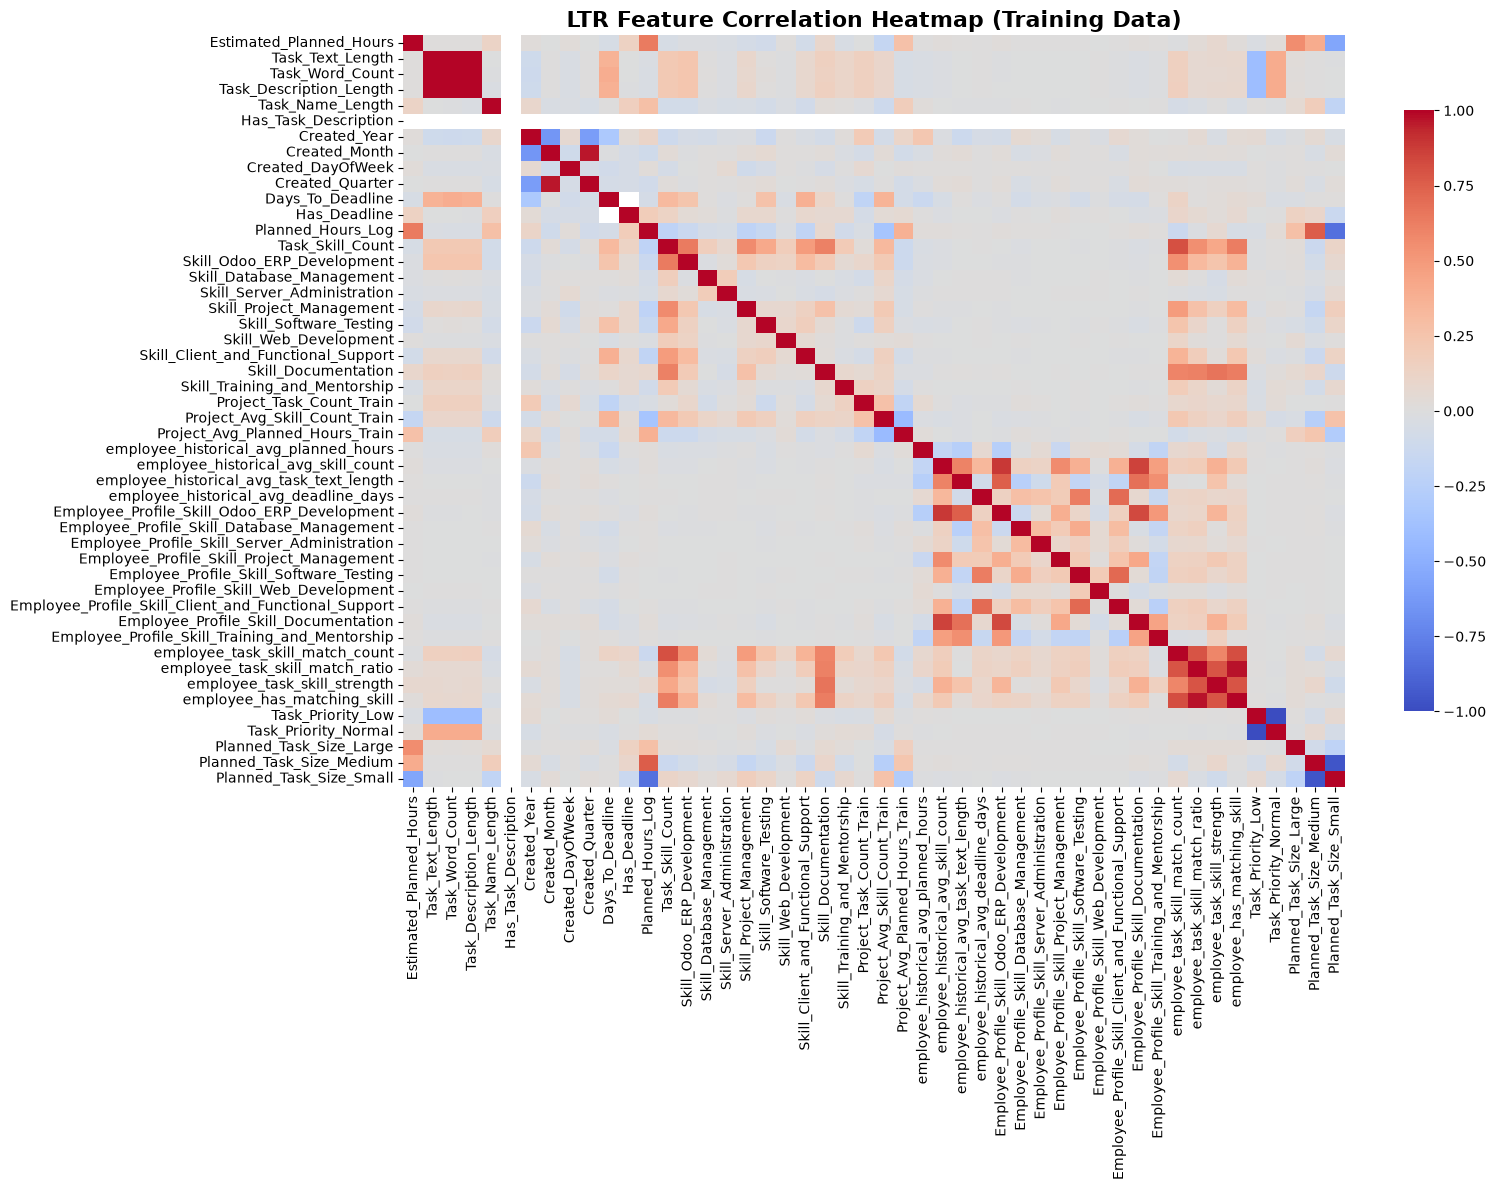

Heatmap saved to: ../results/figures/feature_correlation_heatmap.png


In [11]:
print("--- Selecting Numeric Features for Correlation Analysis ---")

numeric_feature_columns = (
    ltr_train[FEATURE_COLS]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

print(f"Selected {len(numeric_feature_columns)} numeric features for correlation analysis.")

print("--- Generating Correlation Matrix ---")

correlation_matrix = ltr_train[numeric_feature_columns].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'shrink': .8}
)
plt.title("LTR Feature Correlation Heatmap (Training Data)", fontsize=16, fontweight="bold")
plt.tight_layout()

heatmap_path = f"{DIRS['figures']}/feature_correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

print(f"Heatmap saved to: {heatmap_path}")

In [12]:
print("--- Identifying Highly Correlated Feature Pairs ---")

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs["Correlation"].abs() >= 0.85
].sort_values(by="Correlation", key=abs, ascending=False)

high_correlation_path = f"{DIRS['results']}/high_correlation_pairs.csv"
high_correlation_pairs.to_csv(high_correlation_path, index=False)
print(f"Highly correlated feature pairs saved to: {high_correlation_path}")

display(high_correlation_pairs)

--- Identifying Highly Correlated Feature Pairs ---
Highly correlated feature pairs saved to: ../results/high_correlation_pairs.csv


,Feature_1,Feature_2,Correlation
2108,Task_Priority_Low,Task_Priority_Normal,-1.000000
51,Task_Text_Length,Task_Description_Length,0.999722
99,Task_Word_Count,Task_Description_Length,0.998184
50,Task_Text_Length,Task_Word_Count,0.998178
1962,employee_task_skill_match_ratio,employee_has_matching_skill,0.973169
345,Created_Month,Created_Quarter,0.963246
2255,Planned_Task_Size_Medium,Planned_Task_Size_Small,-0.956819
1326,employee_historical_avg_skill_count,Employee_Profile_Skill_Odoo_ERP_Development,0.887660
1333,employee_historical_avg_skill_count,Employee_Profile_Skill_Documentation,0.855147


In [13]:
print("--- Calculating Feature-Target Correlation ---")

feature_target_correlation = (
    ltr_train[numeric_feature_columns + ["relevance"]]
    .corr()["relevance"]
    .drop("relevance")
    .sort_values(key=abs, ascending=False)
)

print(feature_target_correlation.head(15))

target_corr_path = f"{DIRS['results']}/feature_target_correlation.csv"
feature_target_correlation.to_csv(target_corr_path, header=["Correlation"])
print(f"\nFeature-target correlation saved to: {target_corr_path}")

--- Calculating Feature-Target Correlation ---


Task_Word_Count                                   0.141974
Task_Description_Length                           0.141162
Task_Text_Length                                  0.140732
employee_historical_avg_planned_hours             0.083003
employee_task_skill_match_count                   0.077542
Project_Task_Count_Train                          0.057385
employee_task_skill_match_ratio                   0.057259
employee_historical_avg_task_text_length         -0.056249
Employee_Profile_Skill_Training_and_Mentorship   -0.050617
employee_has_matching_skill                       0.050288
Task_Skill_Count                                  0.048573
Employee_Profile_Skill_Odoo_ERP_Development      -0.047113
Task_Priority_Normal                              0.045537
Task_Priority_Low                                -0.045537
Skill_Odoo_ERP_Development                        0.045390
Name: relevance, dtype: float64

Feature-target correlation saved to: ../results/feature_target_correlation.csv


In [14]:
print("--- Step 8. Verify Feature Safety ---")

prohibited_columns = [
    "Task_ID", "Employee_ID", "Employee_Name", "Assigned_Employee_ID",
    "Assigned_Employee_Name", "Hours_Spent", "Actual_Hours_Spent", 
    "Timesheet_Work_Logs", "Timesheet_Logs_Count", "Task_Stage", 
    "All_Collaborating_Employees", "Work_Description", "relevance",
    "Task_Priority_Normal", "Task_Word_Count", "Task_Description_Length", 
    "Created_Quarter", "employee_historical_task_count", 
    "employee_historical_project_count"
]

prohibited_flags = [col for col in numeric_feature_columns if 'FLAG_LEAKAGE' in col]

all_prohibited = prohibited_columns + prohibited_flags

final_feature_columns = [col for col in numeric_feature_columns if col not in all_prohibited]

leakage_detected = [col for col in final_feature_columns if col in all_prohibited]

if leakage_detected:
    raise ValueError(f"FATAL LEAKAGE DETECTED: {leakage_detected}. Stop execution and fix the dataset!")

print(f"Number of final model features: {len(final_feature_columns)}\n")
print("List of final model features:")
for idx, feature in enumerate(final_feature_columns, 1):
    print(f"  {idx:02d}. {feature}")

--- Step 8. Verify Feature Safety ---
Number of final model features: 44

List of final model features:
  01. Estimated_Planned_Hours
  02. Task_Text_Length
  03. Task_Name_Length
  04. Has_Task_Description
  05. Created_Year
  06. Created_Month
  07. Created_DayOfWeek
  08. Days_To_Deadline
  09. Has_Deadline
  10. Planned_Hours_Log
  11. Task_Skill_Count
  12. Skill_Odoo_ERP_Development
  13. Skill_Database_Management
  14. Skill_Server_Administration
  15. Skill_Project_Management
  16. Skill_Software_Testing
  17. Skill_Web_Development
  18. Skill_Client_and_Functional_Support
  19. Skill_Documentation
  20. Skill_Training_and_Mentorship
  21. Project_Task_Count_Train
  22. Project_Avg_Skill_Count_Train
  23. Project_Avg_Planned_Hours_Train
  24. employee_historical_avg_planned_hours
  25. employee_historical_avg_skill_count
  26. employee_historical_avg_task_text_length
  27. employee_historical_avg_deadline_days
  28. Employee_Profile_Skill_Odoo_ERP_Development
  29. Employee_Pro

In [15]:
FEATURE_COLS = final_feature_columns.copy()
assert len(FEATURE_COLS) > 0
assert not any(c.startswith("FLAG_LEAKAGE_") for c in FEATURE_COLS)
assert "Hours_Spent" not in FEATURE_COLS
assert "Work_Description" not in FEATURE_COLS
print(f"FINAL AUTHORITATIVE FEATURE LIST: {len(FEATURE_COLS)} features")

X_train = ltr_train[FEATURE_COLS].copy()
X_val = ltr_val[FEATURE_COLS].copy()
X_test = ltr_test[FEATURE_COLS].copy()

y_train = ltr_train["relevance"].copy()
y_val = ltr_val["relevance"].copy()
y_test = ltr_test["relevance"].copy()

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


FINAL AUTHORITATIVE FEATURE LIST: 44 features
X_train shape: (83741, 44), y_train shape: (83741,)
X_val shape: (17934, 44), y_val shape: (17934,)
X_test shape: (17983, 44), y_test shape: (17983,)


In [16]:
print("--- Step 10. Create a Non-ML Baseline ---")

from sklearn.metrics import ndcg_score

def evaluate_ranking_metrics(df, score_col, k_list=[1, 3, 5]):
    """
    Evaluates ranking performance using Hit@K, MRR, and NDCG.
    Groups predictions by Task_ID and compares sorted scores against relevance.
    """
    results = {f'Hit@{k}': [] for k in k_list}
    results['MRR'] = []
    results['NDCG@5'] = []
    
    for task_id, group in df.groupby('Task_ID'):
        y_true = group['relevance'].values
        y_scores = group[score_col].values
        
        sorted_indices = np.argsort(-y_scores, kind='mergesort')
        sorted_y_true = y_true[sorted_indices]
        
        for k in k_list:
            results[f'Hit@{k}'].append(1 if np.sum(sorted_y_true[:k]) > 0 else 0)
            
        relevant_ranks = np.where(sorted_y_true == 1)[0]
        if len(relevant_ranks) > 0:
            first_relevant_rank = relevant_ranks[0] + 1
            results['MRR'].append(1.0 / first_relevant_rank)
        else:
            results['MRR'].append(0.0)
            
        if np.sum(y_true) > 0:
            # sklearn's ndcg_score expects 2D arrays: shape (n_samples, n_labels)
            results['NDCG@5'].append(ndcg_score([y_true], [y_scores], k=5))
        else:
            results['NDCG@5'].append(0.0)
            
    # Calculate and return means across all tasks
    return {k: round(np.mean(v), 4) for k, v in results.items()}

# --- NEW: Helper function to print metrics clearly ---
def print_metrics_clearly(metrics_dict, title):
    print(f"\n{title}")
    print("=" * 40)
    for metric, value in metrics_dict.items():
        print(f"| {metric:<10} | {value:>10.4f} |")
    print("=" * 40)

# 1. Global Historical Frequency Baseline
global_baseline_metrics = evaluate_ranking_metrics(ltr_test, 'employee_historical_task_count')
print_metrics_clearly(global_baseline_metrics, "GLOBAL HISTORICAL BASELINE")

# 2. Project-Aware Historical Frequency Baseline
max_global_tasks = ltr_train['employee_historical_task_count'].max()
multiplier = max_global_tasks * 10 # Guarantee project experience outweighs global experience

ltr_test['project_aware_score'] = (
    (ltr_test['employee_project_task_count'] * multiplier) + 
    ltr_test['employee_historical_task_count']
)

project_baseline_metrics = evaluate_ranking_metrics(ltr_test, 'project_aware_score')
print_metrics_clearly(project_baseline_metrics, "PROJECT-AWARE BASELINE")

# 3. Save Baseline Results
baseline_results = {
    "global_historical_baseline": global_baseline_metrics,
    "project_aware_baseline": project_baseline_metrics
}

baseline_path = f"{DIRS['results']}/baseline_results.json"
with open(baseline_path, 'w') as f:
    json.dump(baseline_results, f, indent=4)

print(f"\n✅ Baseline results saved to: {baseline_path}")

--- Step 10. Create a Non-ML Baseline ---

GLOBAL HISTORICAL BASELINE
| Hit@1      |     0.0872 |
| Hit@3      |     0.2316 |
| Hit@5      |     0.3379 |
| MRR        |     0.2240 |
| NDCG@5     |     0.1922 |

PROJECT-AWARE BASELINE
| Hit@1      |     0.2970 |
| Hit@3      |     0.4796 |
| Hit@5      |     0.5777 |
| MRR        |     0.4414 |
| NDCG@5     |     0.4150 |

✅ Baseline results saved to: ../results/baseline_results.json


In [18]:
print("=" * 80)
print("STEP 3: LOGISTIC REGRESSION (BALANCED)")
print("=" * 80)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
        solver='lbfgs',
        n_jobs=-1
    ))
])

# Prepare common numeric feature matrices.
# The imputer is fitted only on training data to prevent data leakage.
imputer = SimpleImputer(strategy="median")

X_train_sklearn = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=FEATURE_COLS,
    index=X_train.index
)
X_val_sklearn = pd.DataFrame(
    imputer.transform(X_val),
    columns=FEATURE_COLS,
    index=X_val.index
)
X_test_sklearn = pd.DataFrame(
    imputer.transform(X_test),
    columns=FEATURE_COLS,
    index=X_test.index
)

# Reuse the same processed matrices for XGBoost cells.
X_train_xgb = X_train_sklearn
X_val_xgb = X_val_sklearn
X_test_xgb = X_test_sklearn

logistic_pipeline.fit(X_train_sklearn, y_train)

y_test_pred_proba = logistic_pipeline.predict_proba(X_test_sklearn)[:, 1]

logistic_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
logistic_predictions['prediction_score'] = y_test_pred_proba
logistic_predictions['predicted_label'] = (y_test_pred_proba > 0.5).astype(int)

logistic_predictions.to_csv(f"{DIRS['results']}/logistic_predictions.csv", index=False)

if 'evaluate_ranking_metrics' in globals():
    logreg_metrics = evaluate_ranking_metrics(logistic_predictions, 'prediction_score')
    if 'print_metrics_clearly' in globals():
        print_metrics_clearly(logreg_metrics, "LOGISTIC REGRESSION (BALANCED)")


STEP 3: LOGISTIC REGRESSION (BALANCED)


/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



LOGISTIC REGRESSION (BALANCED)
| Hit@1      |     0.0790 |
| Hit@3      |     0.1717 |
| Hit@5      |     0.3324 |
| MRR        |     0.2095 |
| NDCG@5     |     0.1794 |


In [19]:
print("--- Step 13. Compare Model Against Baseline ---")

baseline_path = f"{DIRS['results']}/baseline_results.json"
with open(baseline_path, 'r') as f:
    saved_baselines = json.load(f)

project_baseline = saved_baselines["project_aware_baseline"]

comparison_df = pd.DataFrame({
    "Metric": list(project_baseline.keys()),
    "Project_Aware_Baseline": list(project_baseline.values()),
    "Logistic_Regression": list(logreg_metrics.values())
})

comparison_df["Difference"] = (
    comparison_df["Logistic_Regression"] - comparison_df["Project_Aware_Baseline"]
)

print("\n🔍 LOGISTIC REGRESSION vs PROJECT-AWARE BASELINE")
print("=" * 65)
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 65)

if comparison_df.loc[comparison_df['Metric'] == 'NDCG@5', 'Difference'].values[0] < 0:
    print("\nInsight: Logistic Regression lost to the baseline on NDCG@5.")
    print("Linear models struggle to rank imbalanced binary labels properly.")

--- Step 13. Compare Model Against Baseline ---

🔍 LOGISTIC REGRESSION vs PROJECT-AWARE BASELINE
Metric  Project_Aware_Baseline  Logistic_Regression  Difference
 Hit@1                  0.2970               0.0790     -0.2180
 Hit@3                  0.4796               0.1717     -0.3079
 Hit@5                  0.5777               0.3324     -0.2453
   MRR                  0.4414               0.2095     -0.2319
NDCG@5                  0.4150               0.1794     -0.2356

Insight: Logistic Regression lost to the baseline on NDCG@5.
Linear models struggle to rank imbalanced binary labels properly.


In [20]:
print("=" * 80)
print("STEP 4: RANDOM FOREST (BALANCED + REGULARIZED)")
print("=" * 80)

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_sklearn, y_train)

y_test_pred_proba = random_forest_model.predict_proba(X_test_sklearn)[:, 1]

random_forest_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
random_forest_predictions['prediction_score'] = y_test_pred_proba
random_forest_predictions['predicted_label'] = (y_test_pred_proba > 0.5).astype(int)

random_forest_predictions.to_csv(f"{DIRS['results']}/random_forest_predictions.csv", index=False)

rf_feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": random_forest_model.feature_importances_
}).sort_values("importance", ascending=False)
rf_feature_importance.to_csv(f"{DIRS['results']}/random_forest_feature_importance.csv", index=False)

if 'evaluate_ranking_metrics' in globals():
    rf_metrics = evaluate_ranking_metrics(random_forest_predictions, 'prediction_score')
    if 'print_metrics_clearly' in globals():
        print_metrics_clearly(rf_metrics, "RANDOM FOREST (BALANCED)")


STEP 4: RANDOM FOREST (BALANCED + REGULARIZED)

RANDOM FOREST (BALANCED)
| Hit@1      |     0.4251 |
| Hit@3      |     0.6921 |
| Hit@5      |     0.7956 |
| MRR        |     0.5902 |
| NDCG@5     |     0.5999 |


In [21]:
print("=" * 80)
print("STEP 5: XGBOOST CLASSIFIER")
print("=" * 80)

from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_classifier.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

y_test_pred_proba = xgb_classifier.predict_proba(X_test_xgb)[:, 1]

xgboost_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
xgboost_predictions['prediction_score'] = y_test_pred_proba
xgboost_predictions['predicted_label'] = (y_test_pred_proba > 0.5).astype(int)

xgboost_predictions.to_csv(f"{DIRS['results']}/xgboost_predictions.csv", index=False)

xgb_feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_classifier.feature_importances_
}).sort_values("importance", ascending=False)
xgb_feature_importance.to_csv(f"{DIRS['results']}/xgboost_feature_importance.csv", index=False)

if 'evaluate_ranking_metrics' in globals():
    xgb_metrics = evaluate_ranking_metrics(xgboost_predictions, 'prediction_score')
    if 'print_metrics_clearly' in globals():
        print_metrics_clearly(xgb_metrics, "XGBOOST CLASSIFIER")


STEP 5: XGBOOST CLASSIFIER

XGBOOST CLASSIFIER
| Hit@1      |     0.4687 |
| Hit@3      |     0.7330 |
| Hit@5      |     0.8256 |
| MRR        |     0.6253 |
| NDCG@5     |     0.6361 |


In [22]:
print("=" * 80)
print("STEP 6: XGBOOST RANKER (PRIMARY MODEL)")
print("=" * 80)

import xgboost as xgb_native

# Build DMatrix with group structure
dtrain_rank = xgb_native.DMatrix(X_train_xgb, label=y_train, feature_names=FEATURE_COLS)
dval_rank   = xgb_native.DMatrix(X_val_xgb,   label=y_val,   feature_names=FEATURE_COLS)
dtest_rank  = xgb_native.DMatrix(X_test_xgb,  label=y_test,  feature_names=FEATURE_COLS)

# Set group sizes
dtrain_rank.set_group(train_groups)
dval_rank.set_group(val_groups)
dtest_rank.set_group(test_groups)

# Verify alignment
assert sum(train_groups) == len(X_train_xgb), f"Train group mismatch: {sum(train_groups)} vs {len(X_train_xgb)}"
assert sum(val_groups) == len(X_val_xgb), f"Val group mismatch: {sum(val_groups)} vs {len(X_val_xgb)}"
assert sum(test_groups) == len(X_test_xgb), f"Test group mismatch: {sum(test_groups)} vs {len(X_test_xgb)}"
print("Group sizes validated")

xgb_rank_params = {
    "objective": "rank:ndcg",
    "eval_metric": ["ndcg@5", "map@5"],
    "eta": 0.05,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.1,
    "lambda": 1.0,
    "seed": 42,
    "tree_method": "hist",
    "verbosity": 1,
}

# FIX A: Train without early_stopping — ranker improvement pattern differs from classifier.
# Fixed rounds prevents the ranker from aborting at iteration 0.
NUM_BOOST_ROUNDS = 200
print(f"\nTraining XGBoost Ranker for {NUM_BOOST_ROUNDS} rounds (fixed, no early stopping)...")

xgb_ranker_model = xgb_native.train(
    xgb_rank_params,
    dtrain_rank,
    num_boost_round=NUM_BOOST_ROUNDS,
    evals=[(dtrain_rank, "train"), (dval_rank, "val")],
    verbose_eval=50,
)

# Predictions — use full trained model
xgb_ranker_predictions = ltr_test[["Task_ID", "Employee_ID", "relevance"]].copy()
xgb_ranker_predictions["prediction_score"] = xgb_ranker_model.predict(dtest_rank)
xgb_ranker_predictions["predicted_label"] = (xgb_ranker_predictions["prediction_score"] > 0.5).astype(int)

xgb_ranker_predictions.to_csv(f"{DIRS['results']}/xgboost_ranker_predictions.csv", index=False)
xgb_ranker_model.save_model(f"{DIRS['models']}/xgboost_ranker.json")

if "evaluate_ranking_metrics" in globals():
    xgb_rank_metrics = evaluate_ranking_metrics(xgb_ranker_predictions, "prediction_score")
    if "print_metrics_clearly" in globals():
        print_metrics_clearly(xgb_rank_metrics, "XGBOOST RANKER (PRIMARY - FIXED)")

# Feature importance
xgb_rank_fi = xgb_ranker_model.get_score(importance_type="gain")
xgb_rank_fi_df = pd.DataFrame([{"feature": k, "importance_gain": v} for k, v in xgb_rank_fi.items()]).sort_values("importance_gain", ascending=False)
xgb_rank_fi_df.to_csv(f"{DIRS['results']}/xgboost_ranker_feature_importance.csv", index=False)

STEP 6: XGBOOST RANKER (PRIMARY MODEL)
Group sizes validated

Training XGBoost Ranker for 200 rounds (fixed, no early stopping)...
[0]	train-ndcg@5:0.29146	train-map@5:0.23071	val-ndcg@5:0.29060	val-map@5:0.23275
[50]	train-ndcg@5:0.61300	train-map@5:0.54582	val-ndcg@5:0.52908	val-map@5:0.45641
[100]	train-ndcg@5:0.68095	train-map@5:0.61814	val-ndcg@5:0.57070	val-map@5:0.49922
[150]	train-ndcg@5:0.75072	train-map@5:0.69898	val-ndcg@5:0.60612	val-map@5:0.53498
[199]	train-ndcg@5:0.79561	train-map@5:0.75125	val-ndcg@5:0.62540	val-map@5:0.56434

XGBOOST RANKER (PRIMARY - FIXED)
| Hit@1      |     0.4632 |
| Hit@3      |     0.6730 |
| Hit@5      |     0.8011 |
| MRR        |     0.6099 |
| NDCG@5     |     0.6096 |


In [23]:
print("--- Section 10: LightGBM Classification ---")
print("--- Step 17. Train LightGBM Classifier ---")

import lightgbm as lgb
from lightgbm import LGBMClassifier

lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Fitting LightGBM model on training data (with early stopping monitoring)...")
lightgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(0)
    ]
)


print("\n--- Step 18. Generate LightGBM Predictions ---")

lgb_pred = lightgbm_model.predict(X_test)
lgb_scores = lightgbm_model.predict_proba(X_test)[:, 1]

lightgbm_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
lightgbm_predictions['prediction_score'] = lgb_scores
lightgbm_predictions['predicted_label'] = lgb_pred

lgb_preds_path = f"{DIRS['results']}/lightgbm_predictions.csv"
lightgbm_predictions.to_csv(lgb_preds_path, index=False)
print(f"LightGBM predictions saved to: {lgb_preds_path}")

# LightGBM was trained using X_train, which contains FEATURE_COLS.
# Use the same feature list to keep both arrays aligned.
lgb_feature_names = list(X_train.columns)
lgb_importances = lightgbm_model.feature_importances_

if len(lgb_feature_names) != len(lgb_importances):
    raise ValueError(
        f"Feature importance mismatch: "
        f"{len(lgb_feature_names)} feature names vs "
        f"{len(lgb_importances)} importance values"
    )

lgb_feature_importance = (
    pd.DataFrame({
        "feature": lgb_feature_names,
        "importance": lgb_importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

lgb_fi_path = f"{DIRS['results']}/lightgbm_feature_importance.csv"
lgb_feature_importance.to_csv(lgb_fi_path, index=False)
print(f"LightGBM feature importance saved to: {lgb_fi_path}")

print("\nEvaluating LightGBM Ranking Performance...")
lgb_metrics = evaluate_ranking_metrics(lightgbm_predictions, 'prediction_score')
print_metrics_clearly(lgb_metrics, "⚡ LIGHTGBM CLASSIFIER")

comparison_df["LightGBM"] = list(lgb_metrics.values())
comparison_df["Random_Forest"] = comparison_df["Metric"].map(rf_metrics)
comparison_df["XGBoost"] = comparison_df["Metric"].map(xgb_metrics)

comparison_df["LGB_vs_RF_Diff"] = (
    comparison_df["LightGBM"] - comparison_df["Random_Forest"]
)

print("\nULTIMATE MODEL COMPARISON (BASELINE vs LOGREG vs RF vs XGBOOST vs LIGHTGBM)")
print("=" * 110)
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 110)

--- Section 10: LightGBM Classification ---
--- Step 17. Train LightGBM Classifier ---
Fitting LightGBM model on training data (with early stopping monitoring)...


/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 2425, number of negative: 81316
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 83741, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028958 -> initscore=-3.512511
[LightGBM] [Info] Start training from score -3.512511

--- Step 18. Generate LightGBM Predictions ---
LightGBM predictions saved to: ../results/lightgbm_predictions.csv
LightGBM feature importance saved to: ../results/lightgbm_feature_importance.csv

Evaluating LightGBM Ranking Performance...

⚡ LIGHTGBM CLASSIFIER
| Hit@1      |     0.4850 |
| Hit@3      |     0.7357 |
| Hit@5      |     0.8229 |
| MRR        |     0.6339 |
| NDCG@5     |     0.6376 |

ULTIMATE MODEL COMPARISON (BASELINE vs 

In [24]:
print("--- Section 10: Classification Evaluation ---")
print("--- Step 17. Calculate Classification Metrics ---")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

ltr_test_eval = ltr_test.copy()
ltr_test_eval['baseline_pred'] = 0
top1_indices = ltr_test_eval.groupby('Task_ID')['project_aware_score'].idxmax()
ltr_test_eval.loc[top1_indices, 'baseline_pred'] = 1

models_to_evaluate = {
    "Historical Baseline": {
        "y_true": ltr_test_eval['relevance'],
        "y_pred": ltr_test_eval['baseline_pred'],
        "y_score": ltr_test_eval['project_aware_score']
    },
    "Logistic Regression": {
        "y_true": logistic_predictions['relevance'],
        "y_pred": logistic_predictions['predicted_label'],
        "y_score": logistic_predictions['prediction_score']
    },
    "Random Forest": {
        "y_true": random_forest_predictions['relevance'],
        "y_pred": random_forest_predictions['predicted_label'],
        "y_score": random_forest_predictions['prediction_score']
    },
    "XGBoost Classifier": {
        "y_true": xgboost_predictions['relevance'],
        "y_pred": xgboost_predictions['predicted_label'],
        "y_score": xgboost_predictions['prediction_score']
    },
    "LightGBM Classifier": {
        "y_true": lightgbm_predictions['relevance'],
        "y_pred": lightgbm_predictions['predicted_label'],
        "y_score": lightgbm_predictions['prediction_score']
    }
}

metrics_records = []
for model_name, data in models_to_evaluate.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    y_score = data["y_score"]
    
    metrics_records.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    })

class_metrics_df = pd.DataFrame(metrics_records)

print("\nCLASSIFICATION METRICS COMPARISON")
print("=" * 85)
print(class_metrics_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 85)
print("\n* Important Note: Because the business requirement is ranking employees (finding the best match)")
print("* rather than absolute binary classification, these classification metrics should be treated as ")
print("* secondary to the Hit@K and NDCG@5 ranking metrics evaluated previously.")

# 5. Save the metrics
class_metrics_path = f"{DIRS['results']}/classification_metrics.csv"
class_metrics_df.to_csv(class_metrics_path, index=False)
print(f"\nClassification metrics saved to: {class_metrics_path}")

--- Section 10: Classification Evaluation ---
--- Step 17. Calculate Classification Metrics ---

CLASSIFICATION METRICS COMPARISON
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Historical Baseline    0.9646     0.2970  0.2238 0.2553   0.8121  0.1175
Logistic Regression    0.6889     0.0634  0.7618 0.1171   0.7778  0.0904
      Random Forest    0.8592     0.1424  0.8357 0.2433   0.9236  0.3456
 XGBoost Classifier    0.9751     0.7857  0.1129 0.1975   0.9325  0.4234
LightGBM Classifier    0.9751     0.7468  0.1211 0.2085   0.9343  0.4335

* Important Note: Because the business requirement is ranking employees (finding the best match)
* rather than absolute binary classification, these classification metrics should be treated as 
* secondary to the Hit@K and NDCG@5 ranking metrics evaluated previously.

Classification metrics saved to: ../results/classification_metrics.csv


In [25]:
print("--- Diagnostic: Overfitting Check (Train vs Test) ---")

from sklearn.metrics import roc_auc_score

# 1. Generate Training Probabilities
rf_train_proba = random_forest_model.predict_proba(X_train)[:, 1]
xgb_train_proba = xgb_classifier.predict_proba(X_train)[:, 1]
lgb_train_proba = lightgbm_model.predict_proba(X_train)[:, 1]

# 2. Retrieve Test Probabilities (already generated in previous steps)
rf_test_proba = random_forest_predictions['prediction_score']
xgb_test_proba = xgboost_predictions['prediction_score']
lgb_test_proba = lightgbm_predictions['prediction_score']

# 3. Compare ROC-AUC
diagnostic_data = {
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Train ROC-AUC": [
        roc_auc_score(y_train, rf_train_proba),
        roc_auc_score(y_train, xgb_train_proba),
        roc_auc_score(y_train, lgb_train_proba)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, rf_test_proba),
        roc_auc_score(y_test, xgb_test_proba),
        roc_auc_score(y_test, lgb_test_proba)
    ]
}

diagnostic_df = pd.DataFrame(diagnostic_data)
diagnostic_df["Drop-off (Overfit Penalty)"] = diagnostic_df["Train ROC-AUC"] - diagnostic_df["Test ROC-AUC"]

print("\n🔍 OVERFITTING DIAGNOSTIC (ROC-AUC)")
print("=" * 65)
print(diagnostic_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 65)

--- Diagnostic: Overfitting Check (Train vs Test) ---

🔍 OVERFITTING DIAGNOSTIC (ROC-AUC)
        Model  Train ROC-AUC  Test ROC-AUC  Drop-off (Overfit Penalty)
Random Forest         0.9789        0.9236                      0.0553
      XGBoost         0.9752        0.9325                      0.0427
     LightGBM         0.9849        0.9343                      0.0506


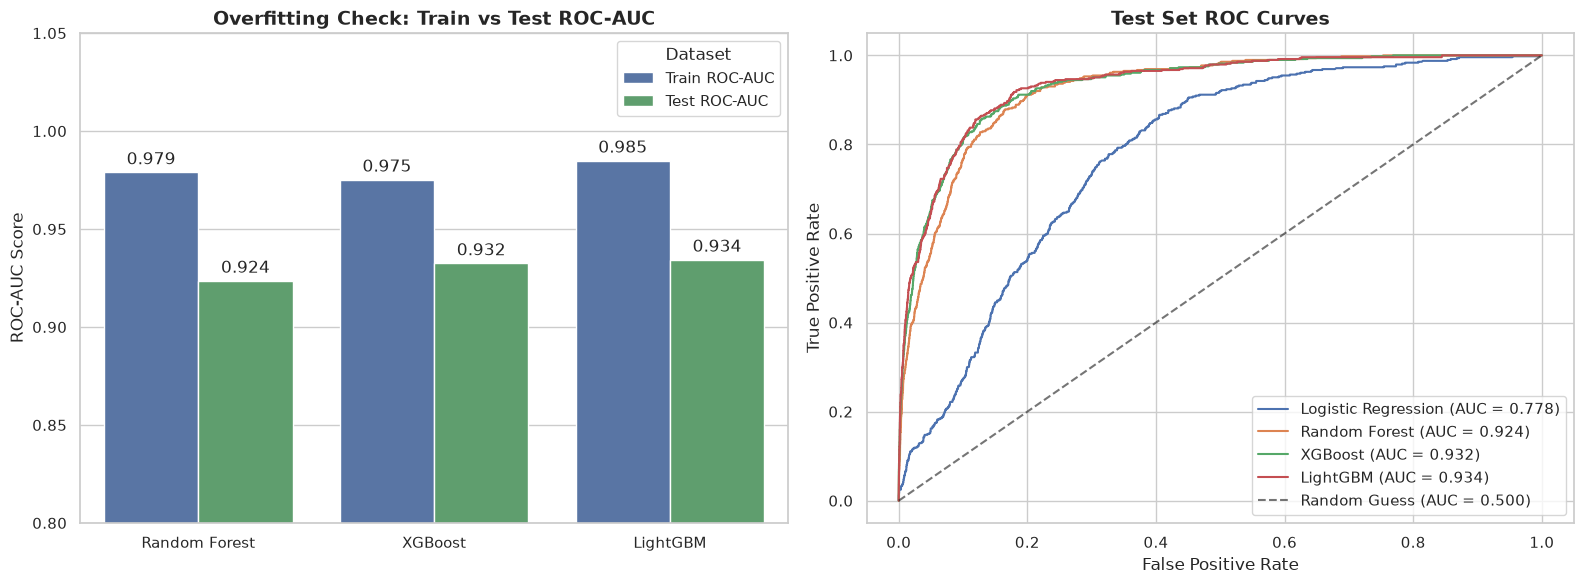


✅ EDA Visualizations saved to: ../results/figures/overfitting_roc_eda.png


In [26]:
from sklearn.metrics import roc_auc_score, roc_curve
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

melted_df = diagnostic_df.melt(id_vars="Model", value_vars=["Train ROC-AUC", "Test ROC-AUC"], 
                               var_name="Dataset", value_name="ROC-AUC Score")

sns.barplot(data=melted_df, x="Model", y="ROC-AUC Score", hue="Dataset", ax=axes[0], palette=["#4C72B0", "#55A868"])
axes[0].set_title("Overfitting Check: Train vs Test ROC-AUC", fontsize=14, fontweight='bold')
axes[0].set_ylim(0.8, 1.05) 
axes[0].set_ylabel("ROC-AUC Score", fontsize=12)
axes[0].set_xlabel("")

for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

models_probas = {
    "Logistic Regression": logistic_predictions['prediction_score'],
    "Random Forest": rf_test_proba,
    "XGBoost": xgb_test_proba,
    "LightGBM": lgb_test_proba
}

for model_name, probas in models_probas.items():
    fpr, tpr, _ = roc_curve(y_test, probas)
    auc_score = roc_auc_score(y_test, probas)
    axes[1].plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Random Guess (AUC = 0.500)")
axes[1].set_title("Test Set ROC Curves", fontsize=14, fontweight='bold')
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()

eda_plot_path = f"{DIRS['figures']}/overfitting_roc_eda.png"
plt.savefig(eda_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ EDA Visualizations saved to: {eda_plot_path}")

In [27]:
print("--- Section 11: Ranking Evaluation ---")
print("--- Step 18, 19, 20. Comprehensive Ranking Evaluation ---")

import pandas as pd
import numpy as np
from sklearn.metrics import ndcg_score

eval_df = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
eval_df['Historical Baseline'] = ltr_test['project_aware_score']
eval_df['Logistic Regression'] = logistic_predictions['prediction_score']
eval_df['Random Forest'] = random_forest_predictions['prediction_score']
eval_df['XGBoost Classifier'] = xgboost_predictions['prediction_score']
eval_df['LightGBM Classifier'] = lightgbm_predictions['prediction_score']

task_pos_counts = eval_df.groupby('Task_ID')['relevance'].sum()
single_pos_tasks = task_pos_counts[task_pos_counts == 1].index
multi_pos_tasks = task_pos_counts[task_pos_counts > 1].index

def get_ranking_metrics_for_subset(df, task_list, score_col, k_list=[1, 3, 5]):
    """Calculates ranking metrics for a specific subset of tasks."""
    subset_df = df[df['Task_ID'].isin(task_list)]
    results = {f'Top-{k}': [] for k in k_list}
    results['MRR'] = []
    results['NDCG@5'] = []
    
    for task_id, group in subset_df.groupby('Task_ID'):
        y_true = group['relevance'].values
        y_scores = group[score_col].values
        
        sorted_indices = np.argsort(-y_scores, kind='mergesort')
        sorted_y_true = y_true[sorted_indices]
        
        for k in k_list:
            results[f'Top-{k}'].append(1 if np.sum(sorted_y_true[:k]) > 0 else 0)
            
        relevant_ranks = np.where(sorted_y_true == 1)[0]
        if len(relevant_ranks) > 0:
            results['MRR'].append(1.0 / (relevant_ranks[0] + 1))
        else:
            results['MRR'].append(0.0)
            
        if np.sum(y_true) > 0:
            results['NDCG@5'].append(ndcg_score([y_true], [y_scores], k=5))
        else:
            results['NDCG@5'].append(0.0)
            
    return {k: round(np.mean(v), 4) for k, v in results.items()}

models = [
    'Historical Baseline', 
    'Logistic Regression', 
    'Random Forest', 
    'XGBoost Classifier',
    'LightGBM Classifier'
]

main_metrics_records = []
print("\n🔍 GENERATING RANKING EVALUATION BREAKDOWNS...")

for model in models:
    all_metrics = get_ranking_metrics_for_subset(eval_df, eval_df['Task_ID'].unique(), model)
    all_metrics['Model'] = model
    main_metrics_records.append(all_metrics)
    
    single_metrics = get_ranking_metrics_for_subset(eval_df, single_pos_tasks, model)
    multi_metrics = get_ranking_metrics_for_subset(eval_df, multi_pos_tasks, model)
    
    print(f"\n--- {model} ---")
    print(f"All Tasks:         Top-1: {all_metrics['Top-1']:.4f} | NDCG@5: {all_metrics['NDCG@5']:.4f}")
    print(f"Single Pos Tasks:  Top-1: {single_metrics['Top-1']:.4f} | NDCG@5: {single_metrics['NDCG@5']:.4f}")
    print(f"Multi Pos Tasks:   Top-1: {multi_metrics['Top-1']:.4f} | NDCG@5: {multi_metrics['NDCG@5']:.4f}")

ranking_metrics_df = pd.DataFrame(main_metrics_records)

ranking_metrics_df = ranking_metrics_df[['Model', 'Top-1', 'Top-3', 'Top-5', 'MRR', 'NDCG@5']]

print("\nFINAL RANKING METRICS SUMMARY (ALL TASKS)")
print("=" * 80)
print(ranking_metrics_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 80)

# Save to CSV
ranking_metrics_path = f"{DIRS['results']}/ranking_metrics.csv"
ranking_metrics_df.to_csv(ranking_metrics_path, index=False)
print(f"\nRanking metrics saved to: {ranking_metrics_path}")

--- Section 11: Ranking Evaluation ---
--- Step 18, 19, 20. Comprehensive Ranking Evaluation ---

🔍 GENERATING RANKING EVALUATION BREAKDOWNS...

--- Historical Baseline ---
All Tasks:         Top-1: 0.2970 | NDCG@5: 0.4150
Single Pos Tasks:  Top-1: 0.2572 | NDCG@5: 0.4049
Multi Pos Tasks:   Top-1: 0.5179 | NDCG@5: 0.4705

--- Logistic Regression ---
All Tasks:         Top-1: 0.0790 | NDCG@5: 0.1794
Single Pos Tasks:  Top-1: 0.0675 | NDCG@5: 0.1804
Multi Pos Tasks:   Top-1: 0.1429 | NDCG@5: 0.1738

--- Random Forest ---
All Tasks:         Top-1: 0.4251 | NDCG@5: 0.5999
Single Pos Tasks:  Top-1: 0.4084 | NDCG@5: 0.6088
Multi Pos Tasks:   Top-1: 0.5179 | NDCG@5: 0.5505

--- XGBoost Classifier ---
All Tasks:         Top-1: 0.4687 | NDCG@5: 0.6361
Single Pos Tasks:  Top-1: 0.4566 | NDCG@5: 0.6512
Multi Pos Tasks:   Top-1: 0.5357 | NDCG@5: 0.5522

--- LightGBM Classifier ---
All Tasks:         Top-1: 0.4850 | NDCG@5: 0.6376
Single Pos Tasks:  Top-1: 0.4662 | NDCG@5: 0.6491
Multi Pos Tasks:  

In [28]:
print("=" * 80)
print("STEP 7: MASTER COMPARISON")
print("=" * 80)

# Build eval_df with all model scores
eval_df = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()

# Historical baseline: use employee_historical_task_count if exists, else frequency from pool
if "employee_historical_task_count" in ltr_test.columns:
    eval_df['Historical Baseline'] = ltr_test['employee_historical_task_count']
else:
    # Build from training data
    train_freq = ltr_train[ltr_train['relevance']==1]['Employee_ID'].value_counts().to_dict()
    eval_df['Historical Baseline'] = eval_df['Employee_ID'].map(train_freq).fillna(0)

eval_df['Logistic Regression'] = logistic_predictions['prediction_score']
eval_df['Random Forest'] = random_forest_predictions['prediction_score']
eval_df['XGBoost Classifier'] = xgboost_predictions['prediction_score']
eval_df['XGBoost Ranker'] = xgb_ranker_predictions['prediction_score']
if 'lightgbm_predictions' in globals():
    eval_df['LightGBM Classifier'] = lightgbm_predictions['prediction_score']

models = ['Historical Baseline', 'Logistic Regression', 'Random Forest', 
          'XGBoost Classifier', 'XGBoost Ranker']
if 'lightgbm_predictions' in globals():
    models.append('LightGBM Classifier')

main_metrics = []
for model in models:
    if 'evaluate_ranking_metrics' in globals():
        m = evaluate_ranking_metrics(eval_df, model)
        m['Model'] = model
        main_metrics.append(m)

if main_metrics:
    ranking_metrics_df = pd.DataFrame(main_metrics)[['Model', 'Hit@1', 'Hit@3', 'Hit@5', 'MRR', 'NDCG@5']]
    ranking_metrics_df = ranking_metrics_df.sort_values('NDCG@5', ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("FINAL RANKING METRICS (sorted by NDCG@5)")
    print("=" * 80)
    print(ranking_metrics_df.to_string(index=False, float_format="{:.4f}".format))
    ranking_metrics_df.to_csv(f"{DIRS['results']}/ranking_metrics.csv", index=False)


STEP 7: MASTER COMPARISON

FINAL RANKING METRICS (sorted by NDCG@5)
              Model  Hit@1  Hit@3  Hit@5    MRR  NDCG@5
LightGBM Classifier 0.4850 0.7357 0.8229 0.6339  0.6376
 XGBoost Classifier 0.4687 0.7330 0.8256 0.6253  0.6361
     XGBoost Ranker 0.4632 0.6730 0.8011 0.6099  0.6096
      Random Forest 0.4251 0.6921 0.7956 0.5902  0.5999
Historical Baseline 0.0872 0.2316 0.3379 0.2240  0.1922
Logistic Regression 0.0790 0.1717 0.3324 0.2095  0.1794


In [29]:
print("=" * 80)
print("STEP 8: PER-TIER PERFORMANCE")
print("=" * 80)

# Get employee frequency from training set
train_emp_freq = ltr_train[ltr_train["relevance"]==1].groupby("Employee_ID").size()

def assign_tier(count):
    if count >= 100: return "Head (>=100)"
    elif count >= 30: return "Mid (30-99)"
    else: return "Tail (<30)"

emp_tier_map = train_emp_freq.apply(assign_tier).to_dict()
print(f"Tier distribution: {pd.Series(emp_tier_map).value_counts().to_dict()}")

# FIX B: per_tier_metrics now filters tasks with <2 candidates (NDCG requires >=2)
# and wraps evaluation in try/except to handle edge cases gracefully
def per_tier_metrics(df, score_col, tier_map, model_name):
    df = df.copy()
    df["tier"] = df["Employee_ID"].map(tier_map).fillna("Unknown")
    rows = []
    for tier in ["Head (>=100)", "Mid (30-99)", "Tail (<30)"]:
        tier_df = df[df["tier"] == tier]
        if len(tier_df) == 0 or tier_df["Task_ID"].nunique() == 0:
            print(f"  Skipping {tier} ({model_name}): no candidates in tier")
            continue
        # NDCG requires >= 2 documents per task; filter out single-candidate tasks
        task_sizes = tier_df.groupby("Task_ID").size()
        valid_tasks = task_sizes[task_sizes >= 2].index
        tier_df = tier_df[tier_df["Task_ID"].isin(valid_tasks)]
        if tier_df["Task_ID"].nunique() == 0:
            print(f"  Skipping {tier} ({model_name}): no tasks with >= 2 candidates")
            continue
        try:
            if "evaluate_ranking_metrics" in globals():
                m = evaluate_ranking_metrics(tier_df, score_col)
                m["model"] = model_name
                m["tier"] = tier
                m["n_employees"] = tier_df["Employee_ID"].nunique()
                m["n_tasks"] = tier_df["Task_ID"].nunique()
                rows.append(m)
        except Exception as e:
            print(f"  Skipping {tier} ({model_name}): {e}")
            continue
    return pd.DataFrame(rows)

per_tier_rows = []
models_to_eval = [
    ("XGBoost_Ranker", xgb_ranker_predictions),
    ("XGBoost_Classifier", xgboost_predictions),
    ("Random_Forest", random_forest_predictions)
]
if "lightgbm_predictions" in globals():
    models_to_eval.append(("LightGBM_Classifier", lightgbm_predictions))

for model_name, df in models_to_eval:
    result = per_tier_metrics(df, "prediction_score", emp_tier_map, model_name)
    if not result.empty:
        per_tier_rows.append(result)

if per_tier_rows:
    per_tier_df = pd.concat(per_tier_rows, ignore_index=True)
    per_tier_df = per_tier_df[["model", "tier", "n_employees", "n_tasks", "Hit@1", "Hit@3", "Hit@5", "MRR", "NDCG@5"]]
    print(per_tier_df.to_string(index=False, float_format="{:.4f}".format))
    per_tier_df.to_csv(f"{DIRS['results']}/per_tier_metrics.csv", index=False)

STEP 8: PER-TIER PERFORMANCE
Tier distribution: {'Tail (<30)': 24, 'Mid (30-99)': 16, 'Head (>=100)': 9}
              model         tier  n_employees  n_tasks  Hit@1  Hit@3  Hit@5    MRR  NDCG@5
     XGBoost_Ranker Head (>=100)            9      367 0.3025 0.4659 0.5395 0.3965  0.4245
     XGBoost_Ranker  Mid (30-99)           16      367 0.2725 0.3569 0.3978 0.3234  0.3272
     XGBoost_Ranker   Tail (<30)           24      367 0.0436 0.0790 0.0954 0.0642  0.0678
 XGBoost_Classifier Head (>=100)            9      367 0.3106 0.4687 0.5422 0.4025  0.4317
 XGBoost_Classifier  Mid (30-99)           16      367 0.2725 0.3678 0.3924 0.3274  0.3339
 XGBoost_Classifier   Tail (<30)           24      367 0.0463 0.0736 0.0926 0.0664  0.0697
      Random_Forest Head (>=100)            9      367 0.3052 0.4796 0.5341 0.4010  0.4270
      Random_Forest  Mid (30-99)           16      367 0.2616 0.3678 0.4060 0.3209  0.3311
      Random_Forest   Tail (<30)           24      367 0.0545 0.0872 0.1063 

In [30]:
print("--- Section 13: Feature Importance and Interpretability ---")
print("--- Step 22. Analyze Important Features (XGBoost) ---")

xgb_fi = pd.read_csv(f"{DIRS['results']}/xgboost_feature_importance.csv")

print("\n🚀 XGBOOST - TOP 20 FEATURES")
print("=" * 55)
print(xgb_fi.head(20).to_string(index=False))

def plot_feature_importance(df, title, save_path):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(20), x='importance', y='feature', hue='feature', legend=False, palette='mako')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

xgb_plot_path = f"{DIRS['figures']}/xgboost_feature_importance.png"
plot_feature_importance(xgb_fi, 'XGBoost - Top 20 Features', xgb_plot_path)

print(f"\n✅ XGBoost feature importance plot saved to: {xgb_plot_path}")

--- Section 13: Feature Importance and Interpretability ---
--- Step 22. Analyze Important Features (XGBoost) ---

🚀 XGBOOST - TOP 20 FEATURES
                                             feature  importance
               employee_historical_avg_planned_hours    0.059424
                     employee_task_skill_match_count    0.041960
                                   Planned_Hours_Log    0.039196
                                        Has_Deadline    0.039196
                             Estimated_Planned_Hours    0.039033
Employee_Profile_Skill_Client_and_Functional_Support    0.032793
                                        Created_Year    0.032508
                                    Task_Text_Length    0.032485
          Employee_Profile_Skill_Database_Management    0.031953
           Employee_Profile_Skill_Project_Management    0.029588
                     employee_task_skill_match_ratio    0.029403
                 employee_historical_avg_skill_count    0.028710
            

In [31]:
print("--- Section 14: Save Models and Results ---")
print("--- Step 23. Save Trained Models and Metadata ---")

import joblib
from datetime import datetime

logistic_path = f"{DIRS['models']}/logistic_regression.pkl"
rf_path = f"{DIRS['models']}/random_forest.pkl"
xgb_path = f"{DIRS['models']}/xgboost_classifier.pkl"

joblib.dump(logistic_pipeline, logistic_path)
joblib.dump(random_forest_model, rf_path)
joblib.dump(xgb_classifier, xgb_path)

print(f"Models saved successfully to {DIRS['models']}/")

feature_cols_path = f"{DIRS['models']}/feature_columns.json"
with open(feature_cols_path, 'w') as f:
    json.dump({"features": final_feature_columns}, f, indent=4)
print(f"Feature columns saved to {feature_cols_path}")

# Define the comparison table used in the metadata.
# Section 8 creates ranking_metrics_df; use it as the master comparison.
if "ranking_metrics_df" in globals() and not ranking_metrics_df.empty:
    master_comparison = ranking_metrics_df.copy()
elif "comparison_df" in globals() and not comparison_df.empty:
    master_comparison = comparison_df.copy()
else:
    raise RuntimeError(
        "No comparison dataframe found. Execute the model evaluation cells first."
    )

# Convert NumPy/Pandas values into JSON-compatible Python values.
def make_json_serializable(value):
    if isinstance(value, dict):
        return {key: make_json_serializable(val) for key, val in value.items()}
    if isinstance(value, list):
        return [make_json_serializable(item) for item in value]
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if pd.isna(value):
        return None
    return value

metadata = {
    "training_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_seed": int(RANDOM_STATE),
    "dataset_records": {
        "training_rows": int(len(X_train)),
        "validation_rows": int(len(X_val)),
        "test_rows": int(len(X_test)),
        "number_of_features": int(len(final_feature_columns))
    },
    "dataset_filenames": {
        "train": "feature_engineered_train_dataset.csv",
        "test": "feature_engineered_test_dataset.csv"
    },
    "models": {
        "Logistic_Regression": {
            "hyperparameters": logistic_pipeline.named_steps["logreg"].get_params()
        },
        "Random_Forest": {
            "hyperparameters": random_forest_model.get_params()
        },
        "XGBoost_Classifier": {
            "hyperparameters": xgb_classifier.get_params()
        }
    },
    "evaluation_metrics": {
        "model_comparison_summary": make_json_serializable(
            master_comparison.to_dict(orient="records")
        )
    }
}

metadata_path = f"{DIRS['models']}/model_training_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Training metadata saved to {metadata_path}")
print("\nPipeline Execution Complete! All artifacts, models, and evaluations are securely stored.")

--- Section 14: Save Models and Results ---
--- Step 23. Save Trained Models and Metadata ---
Models saved successfully to ../models/
Feature columns saved to ../models/feature_columns.json
Training metadata saved to ../models/model_training_metadata.json

Pipeline Execution Complete! All artifacts, models, and evaluations are securely stored.


In [ ]:
%pip install optuna



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

print(f"Optuna version: {optuna.__version__}")
print(f"Models available for tuning: XGBoost Classifier, Random Forest")


Optuna version: 5.0.0
Models available for tuning: XGBoost Classifier, Random Forest


/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
# Optuna objective for XGBoost Classifier
# Uses validation set for early stopping, optimizes NDCG@5 via ranking metric
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
    }
    
    # Train with early stopping on validation set
    model = XGBClassifier(**params)
    model.fit(
        X_train_xgb, y_train,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False,
    )
    
    # Predict on validation set
    val_pred = model.predict_proba(X_val_xgb)[:, 1]
    val_df = ltr_val[['Task_ID', 'Employee_ID', 'relevance']].copy()
    val_df['prediction_score'] = val_pred
    
    # Evaluate ranking metrics on validation set
    val_metrics = evaluate_ranking_metrics(val_df, 'prediction_score')
    
    # Return NDCG@5 as objective (ranking-oriented as per plan)
    return val_metrics['NDCG@5']

print("XGBoost objective function defined.")


XGBoost objective function defined.


In [34]:
N_TRIALS = 30
print(f"Starting XGBoost hyperparameter optimization with {N_TRIALS} trials...")
print(f"Optimizing on validation set (test set UNTOUCHED)\n")

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="xgb_ranker_optimization",
)

xgb_study.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)

print(f"\nXGBoost optimization complete!")
print(f"Best NDCG@5 (validation): {xgb_study.best_value:.4f}")
print(f"Best parameters:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")


[I 2026-09-21 15:11:19,192] A new study created in memory with name: xgb_ranker_optimization


Starting XGBoost hyperparameter optimization with 30 trials...
Optimizing on validation set (test set UNTOUCHED)



[I 2026-09-21 15:11:28,368] Trial 0 finished with value: 0.6745 and parameters: {'n_estimators': 400, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.02904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 0.6745.
[I 2026-09-21 15:11:49,579] Trial 1 finished with value: 0.6352 and parameters: {'n_estimators': 600, 'learning_rate': 0.010636066512540286, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.09170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 1.0495128632644757}. Best is trial 0 with value: 0.6745.
[I 2026-09-21 15:11:59,630] Trial 2 finished with value: 0.6776 and parameters: {'n_estimators': 500, 'learning_rate': 0.023927528765580644, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.7168578594140873, 'colsample_byt


XGBoost optimization complete!
Best NDCG@5 (validation): 0.6969
Best parameters:
  n_estimators: 400
  learning_rate: 0.09108180232178145
  max_depth: 8
  min_child_weight: 1
  subsample: 0.9019909933539483
  colsample_bytree: 0.7356747274714761
  gamma: 0.24364539332575133
  reg_alpha: 0.7061010163332531
  reg_lambda: 0.9590937126826384


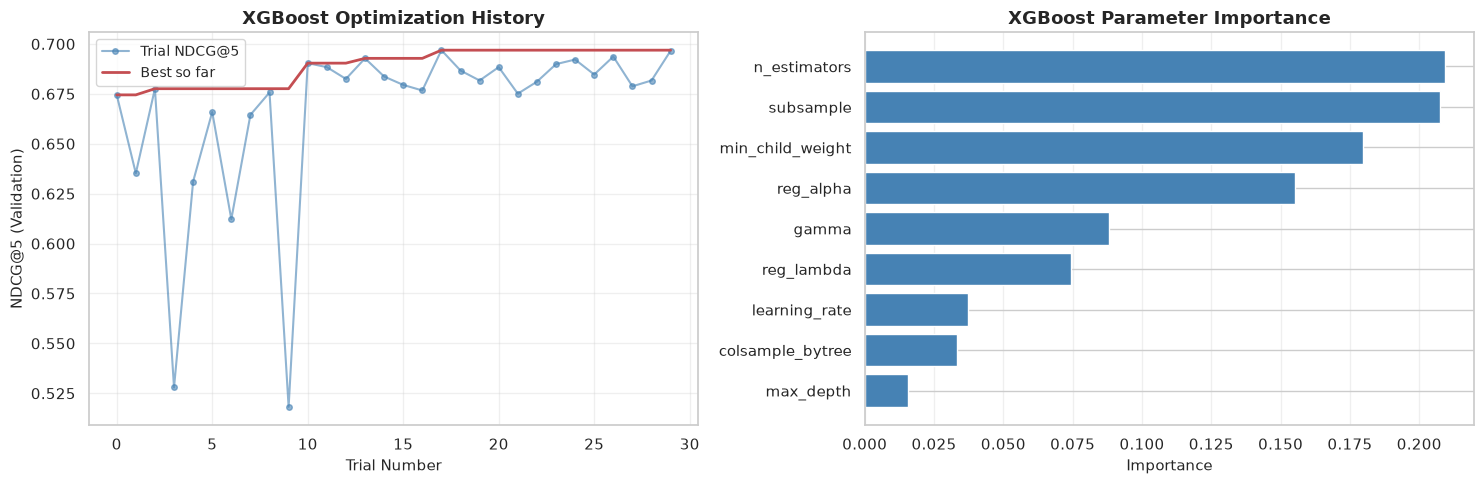

XGBoost Optuna plots saved (matplotlib version).


In [35]:
import matplotlib.pyplot as plt

# Extract trial data
trials = xgb_study.trials
trial_numbers = [t.number for t in trials if t.value is not None]
trial_values = [t.value for t in trials if t.value is not None]
best_values = [max(trial_values[:i+1]) for i in range(len(trial_values))]

# Plot 1: Optimization history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(trial_numbers, trial_values, 'o-', color='steelblue', alpha=0.6, label='Trial NDCG@5', markersize=4)
axes[0].plot(trial_numbers, best_values, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial Number', fontsize=11)
axes[0].set_ylabel('NDCG@5 (Validation)', fontsize=11)
axes[0].set_title('XGBoost Optimization History', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Parameter importance (using Optuna's built-in calc)
try:
    importance = optuna.importance.get_param_importances(xgb_study)
    params = list(importance.keys())
    values = list(importance.values())
    
    axes[1].barh(params[::-1], values[::-1], color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Importance', fontsize=11)
    axes[1].set_title('XGBoost Parameter Importance', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
except Exception as e:
    axes[1].text(0.5, 0.5, f'Param importance unavailable:\n{e}', 
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Parameter Importance (unavailable)', fontsize=13)

plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/xgb_optuna_history.png", dpi=300, bbox_inches='tight')
plt.show()

print("XGBoost Optuna plots saved (matplotlib version).")

In [37]:
X_trainval_xgb = pd.concat([X_train_xgb, X_val_xgb], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

best_xgb_params = xgb_study.best_params.copy()
best_xgb_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "tree_method": "hist",
})

xgb_tuned_model = XGBClassifier(**best_xgb_params)
xgb_tuned_model.fit(X_trainval_xgb, y_trainval, verbose=False)

# TEST DATA IS USED ONLY HERE
xgb_tuned_test_pred = xgb_tuned_model.predict_proba(X_test_xgb)[:, 1]


In [38]:
# Optuna objective for Random Forest
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7]),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
    }
    
    model = RandomForestClassifier(**params)
    model.fit(X_train_sklearn, y_train)
    
    val_pred = model.predict_proba(X_val_sklearn)[:, 1]
    val_df = ltr_val[['Task_ID', 'Employee_ID', 'relevance']].copy()
    val_df['prediction_score'] = val_pred
    
    val_metrics = evaluate_ranking_metrics(val_df, 'prediction_score')
    return val_metrics['NDCG@5']

print("Random Forest objective function defined.")


Random Forest objective function defined.


In [39]:
N_TRIALS_RF = 25
print(f"Starting Random Forest optimization with {N_TRIALS_RF} trials...")

rf_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="rf_ranker_optimization",
)

rf_study.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=False)

print(f"\nRF optimization complete!")
print(f"Best NDCG@5 (validation): {rf_study.best_value:.4f}")
print(f"Best parameters:")
for k, v in rf_study.best_params.items():
    print(f"  {k}: {v}")


[I 2026-09-21 15:21:38,104] A new study created in memory with name: rf_ranker_optimization


Starting Random Forest optimization with 25 trials...


[I 2026-09-21 15:22:18,302] Trial 0 finished with value: 0.6423 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 38, 'min_samples_leaf': 13, 'max_features': 0.7}. Best is trial 0 with value: 0.6423.
[I 2026-09-21 15:22:35,785] Trial 1 finished with value: 0.6252 and parameters: {'n_estimators': 500, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6423.
[I 2026-09-21 15:22:46,218] Trial 2 finished with value: 0.614 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 24, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6423.
[I 2026-09-21 15:23:24,055] Trial 3 finished with value: 0.6388 and parameters: {'n_estimators': 400, 'max_depth': 17, 'min_samples_split': 14, 'min_samples_leaf': 11, 'max_features': 0.5}. Best is trial 0 with value: 0.6423.
[I 2026-09-21 15:23:42,090] Trial 4 finished with value: 0.6318 and parameters: {'n_estimator


RF optimization complete!
Best NDCG@5 (validation): 0.6466
Best parameters:
  n_estimators: 300
  max_depth: 19
  min_samples_split: 36
  min_samples_leaf: 10
  max_features: 0.7


In [40]:
print("Training final Random Forest with best hyperparameters...")

best_rf_params = rf_study.best_params.copy()
best_rf_params.update({
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
})

X_trainval_sklearn = pd.concat([X_train_sklearn, X_val_sklearn], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

rf_tuned_model = RandomForestClassifier(**best_rf_params)
rf_tuned_model.fit(X_trainval_sklearn, y_trainval)

rf_tuned_test_pred = rf_tuned_model.predict_proba(X_test_sklearn)[:, 1]
rf_tuned_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
rf_tuned_predictions['prediction_score'] = rf_tuned_test_pred
rf_tuned_predictions['predicted_label'] = (rf_tuned_test_pred > 0.5).astype(int)

rf_tuned_metrics = evaluate_ranking_metrics(rf_tuned_predictions, 'prediction_score')
print_metrics_clearly(rf_tuned_metrics, "RANDOM FOREST TUNED (TEST SET - First Touch)")

rf_tuned_predictions.to_csv(f"{DIRS['results']}/rf_tuned_predictions.csv", index=False)
joblib.dump(rf_tuned_model, f"{DIRS['models']}/random_forest_tuned.pkl")

print(f"\n{'='*60}")
print(f"COMPARISON: Baseline RF vs Tuned RF")
print(f"{'='*60}")
print(f"Baseline RF NDCG@5: {rf_metrics['NDCG@5']:.4f}")
print(f"Tuned RF NDCG@5:    {rf_tuned_metrics['NDCG@5']:.4f}")
improvement_rf = rf_tuned_metrics['NDCG@5'] - rf_metrics['NDCG@5']
print(f"Improvement: {improvement_rf:+.4f} ({improvement_rf*100:+.2f}%)")


Training final Random Forest with best hyperparameters...

RANDOM FOREST TUNED (TEST SET - First Touch)
| Hit@1      |     0.4823 |
| Hit@3      |     0.7357 |
| Hit@5      |     0.8638 |
| MRR        |     0.6393 |
| NDCG@5     |     0.6535 |

COMPARISON: Baseline RF vs Tuned RF
Baseline RF NDCG@5: 0.5999
Tuned RF NDCG@5:    0.6535
Improvement: +0.0536 (+5.36%)



FINAL MASTER COMPARISON (Including Optuna-Tuned Models)
                        Model  Hit@1  Hit@3  Hit@5    MRR  NDCG@5
   XGBoost Classifier (Tuned) 0.5749 0.8311 0.8992 0.7179  0.7253
        Random Forest (Tuned) 0.4823 0.7357 0.8638 0.6393  0.6535
          LightGBM Classifier 0.4850 0.7357 0.8229 0.6339  0.6376
XGBoost Classifier (Baseline) 0.4687 0.7330 0.8256 0.6253  0.6361
               XGBoost Ranker 0.4632 0.6730 0.8011 0.6099  0.6096
     Random Forest (Baseline) 0.4251 0.6921 0.7956 0.5902  0.5999
          Historical Baseline 0.0872 0.2316 0.3379 0.2240  0.1922
          Logistic Regression 0.0790 0.1717 0.3324 0.2095  0.1794

Saved to ../results/final_comparison_with_tuned.csv


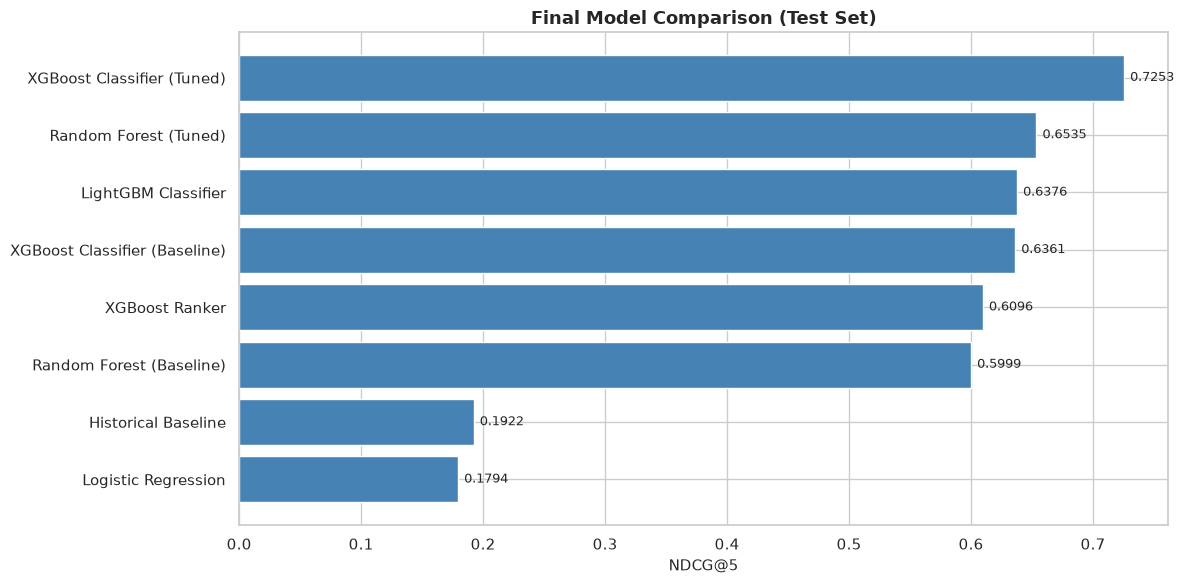

In [42]:
# Final master comparison: all models including tuned versions
tuned_comparison_records = []

# Build predictions and metrics for the tuned XGBoost model
xgb_tuned_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
xgb_tuned_predictions['prediction_score'] = xgb_tuned_test_pred
xgb_tuned_predictions['predicted_label'] = (xgb_tuned_test_pred > 0.5).astype(int)

xgb_tuned_metrics = evaluate_ranking_metrics(
    xgb_tuned_predictions,
    'prediction_score'
)

xgb_tuned_predictions.to_csv(
    f"{DIRS['results']}/xgb_tuned_predictions.csv",
    index=False
)

joblib.dump(
    xgb_tuned_model,
    f"{DIRS['models']}/xgboost_classifier_tuned.pkl"
)

for model_name, df in [
    (
        'Historical Baseline',
        eval_df[
            ['Task_ID', 'Employee_ID', 'relevance', 'Historical Baseline']
        ].rename(columns={'Historical Baseline': 'prediction_score'})
    ),
    ('Logistic Regression', logistic_predictions),
    ('Random Forest (Baseline)', random_forest_predictions),
    ('Random Forest (Tuned)', rf_tuned_predictions),
    ('XGBoost Classifier (Baseline)', xgboost_predictions),
    ('XGBoost Classifier (Tuned)', xgb_tuned_predictions),
    ('LightGBM Classifier', lightgbm_predictions),
    ('XGBoost Ranker', xgb_ranker_predictions),
]:
    metrics = evaluate_ranking_metrics(df, 'prediction_score')
    metrics['Model'] = model_name
    tuned_comparison_records.append(metrics)

tuned_comparison_df = pd.DataFrame(tuned_comparison_records)
tuned_comparison_df = tuned_comparison_df[['Model', 'Hit@1', 'Hit@3', 'Hit@5', 'MRR', 'NDCG@5']]
tuned_comparison_df = tuned_comparison_df.sort_values('NDCG@5', ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MASTER COMPARISON (Including Optuna-Tuned Models)")
print("=" * 100)
print(tuned_comparison_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 100)

tuned_comparison_df.to_csv(f"{DIRS['results']}/final_comparison_with_tuned.csv", index=False)
print(f"\nSaved to {DIRS['results']}/final_comparison_with_tuned.csv")

# Visualize
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(tuned_comparison_df['Model'][::-1], tuned_comparison_df['NDCG@5'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('NDCG@5', fontsize=11)
ax.set_title('Final Model Comparison (Test Set)', fontsize=13, fontweight='bold')
for i, v in enumerate(tuned_comparison_df['NDCG@5'][::-1]):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/final_comparison_tuned.png", dpi=300, bbox_inches='tight')
plt.show()


In [43]:
# Save best hyperparameters for reproducibility
import json
from datetime import datetime

tuning_metadata = {
    "tuning_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "framework": "Optuna",
    "sampler": "TPE",
    "objective_metric": "NDCG@5 on validation set",
    "test_set_status": "UNTOUCHED during optimization",
    "xgb_best_params": xgb_study.best_params,
    "xgb_best_val_ndcg5": float(xgb_study.best_value),
    "xgb_test_ndcg5": float(xgb_tuned_metrics['NDCG@5']),
    "xgb_test_improvement_over_baseline": float(xgb_tuned_metrics['NDCG@5'] - xgb_metrics['NDCG@5']),
    "rf_best_params": rf_study.best_params,
    "rf_best_val_ndcg5": float(rf_study.best_value),
    "rf_test_ndcg5": float(rf_tuned_metrics['NDCG@5']),
    "rf_test_improvement_over_baseline": float(rf_tuned_metrics['NDCG@5'] - rf_metrics['NDCG@5']),
}

with open(f"{DIRS['models']}/optuna_tuning_metadata.json", 'w') as f:
    json.dump(tuning_metadata, f, indent=4)

print("Optuna tuning metadata saved.")
print(f"\nFinal Results Summary:")
print(f"  XGBoost (Baseline) NDCG@5: {xgb_metrics['NDCG@5']:.4f}")
print(f"  XGBoost (Tuned)    NDCG@5: {xgb_tuned_metrics['NDCG@5']:.4f} [{xgb_tuned_metrics['NDCG@5'] - xgb_metrics['NDCG@5']:+.4f}]")
print(f"  RandomForest (Baseline) NDCG@5: {rf_metrics['NDCG@5']:.4f}")
print(f"  RandomForest (Tuned)    NDCG@5: {rf_tuned_metrics['NDCG@5']:.4f} [{rf_tuned_metrics['NDCG@5'] - rf_metrics['NDCG@5']:+.4f}]")

best_overall = tuned_comparison_df.iloc[0]
print(f"\n🏆 Best Model: {best_overall['Model']} (NDCG@5 = {best_overall['NDCG@5']:.4f})")


Optuna tuning metadata saved.

Final Results Summary:
  XGBoost (Baseline) NDCG@5: 0.6361
  XGBoost (Tuned)    NDCG@5: 0.7253 [+0.0892]
  RandomForest (Baseline) NDCG@5: 0.5999
  RandomForest (Tuned)    NDCG@5: 0.6535 [+0.0536]

🏆 Best Model: XGBoost Classifier (Tuned) (NDCG@5 = 0.7253)
